# Eksperimen Machine Learning - Wine Quality Dataset
**Nama:** Moch Mizan Ghodafail  
**Dataset:** Wine Quality Dataset (Red Wine)  
**Deskripsi:** Dataset klasifikasi kualitas anggur merah berdasarkan karakteristik fisikokimia.  
**Tujuan:** EDA dan preprocessing data sebelum pelatihan model


## Setup Environment


In [1]:
# Uncomment jika running di Google Colab
# !pip install scikit-learn pandas numpy matplotlib seaborn

# Jika running di Colab, clone repo terlebih dahulu:
# !git clone https://github.com/mochmizan/Eksperimen_SML_Moch-Mizan-Ghodafail.git
# %cd Eksperimen_SML_Moch-Mizan-Ghodafail/preprocessing


## 1. Import Libraries


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('Libraries imported successfully!')
print(f'Pandas version: {pd.__version__}')
print(f'NumPy version: {np.__version__}')


Libraries imported successfully!
Pandas version: 2.3.3
NumPy version: 2.4.4


## 2. Data Loading


In [3]:
# Cek apakah wine_raw.csv sudah ada
RAW_DATA_PATH = '../wine_raw.csv'

if not os.path.exists(RAW_DATA_PATH):
    print('File wine_raw.csv belum ada. Jalankan generate_raw_data.py di root repository terlebih dahulu.')
else:
    print(f'wine_raw.csv ditemukan di: {os.path.abspath(RAW_DATA_PATH)}')


wine_raw.csv ditemukan di: d:\Coding\Python\finalitas\New folder (2)\Eksperimen_SML_Moch-Mizan-Ghodafail\wine_raw.csv


In [4]:
# Load dataset dari file CSV
df = pd.read_csv(RAW_DATA_PATH)

print('=== Data Berhasil Dimuat ===')
print(f'Shape: {df.shape}')
print(f'Jumlah baris: {df.shape[0]}')
print(f'Jumlah kolom: {df.shape[1]}')
print()
print('5 baris pertama:')
display(df.head())


=== Data Berhasil Dimuat ===
Shape: (1599, 12)
Jumlah baris: 1599
Jumlah kolom: 12

5 baris pertama:


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality_label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,bad
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,bad
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,bad
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,good
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,bad


## 3. Exploratory Data Analysis (EDA)


In [5]:
# Informasi umum dataset
print('=== Informasi Dataset ===')
print(df.info())
print()
print('=== Tipe Data ===')
print(df.dtypes)


=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         1599 non-null   float64
 1   volatile_acidity      1599 non-null   float64
 2   citric_acid           1599 non-null   float64
 3   residual_sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free_sulfur_dioxide   1599 non-null   float64
 6   total_sulfur_dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality_label         1599 non-null   object 
dtypes: float64(11), object(1)
memory usage: 150.0+ KB
None

=== Tipe Data ===
fixed_acidity           float64
volatile_acidity        float64
citric_aci

In [6]:
# Statistik deskriptif
print('=== Statistik Deskriptif ===')
display(df.describe())


=== Statistik Deskriptif ===


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000


In [7]:
# Cek missing values
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing)
print(f'\nTotal missing values: {missing.sum()}')

# Cek duplikat
print(f'\n=== Duplicate Rows ===')
duplicates = df.duplicated().sum()
print(f'Jumlah duplikat: {duplicates}')


=== Missing Values ===
fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality_label           0
dtype: int64

Total missing values: 0

=== Duplicate Rows ===
Jumlah duplikat: 240


=== Distribusi Kelas (quality_label) ===
quality_label
good    855
bad     744
Name: count, dtype: int64

Proporsi kelas:
quality_label
good    0.535
bad     0.465
Name: proportion, dtype: float64


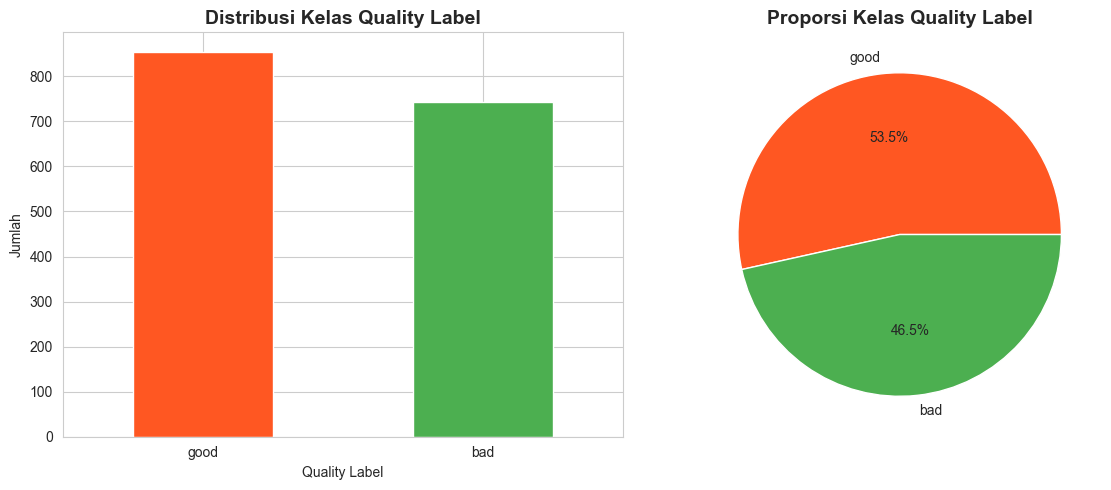

Plot distribusi kelas disimpan.


In [8]:
# Distribusi kelas
print('=== Distribusi Kelas (quality_label) ===')
class_dist = df['quality_label'].value_counts()
print(class_dist)
print(f'\nProporsi kelas:')
print(df['quality_label'].value_counts(normalize=True).round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
class_dist.plot(kind='bar', ax=axes[0], color=['#FF5722', '#4CAF50'])
axes[0].set_title('Distribusi Kelas Quality Label', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Quality Label')
axes[0].set_ylabel('Jumlah')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
axes[1].pie(class_dist.values, labels=class_dist.index, autopct='%1.1f%%',
            colors=['#FF5722', '#4CAF50'])
axes[1].set_title('Proporsi Kelas Quality Label', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print('Plot distribusi kelas disimpan.')


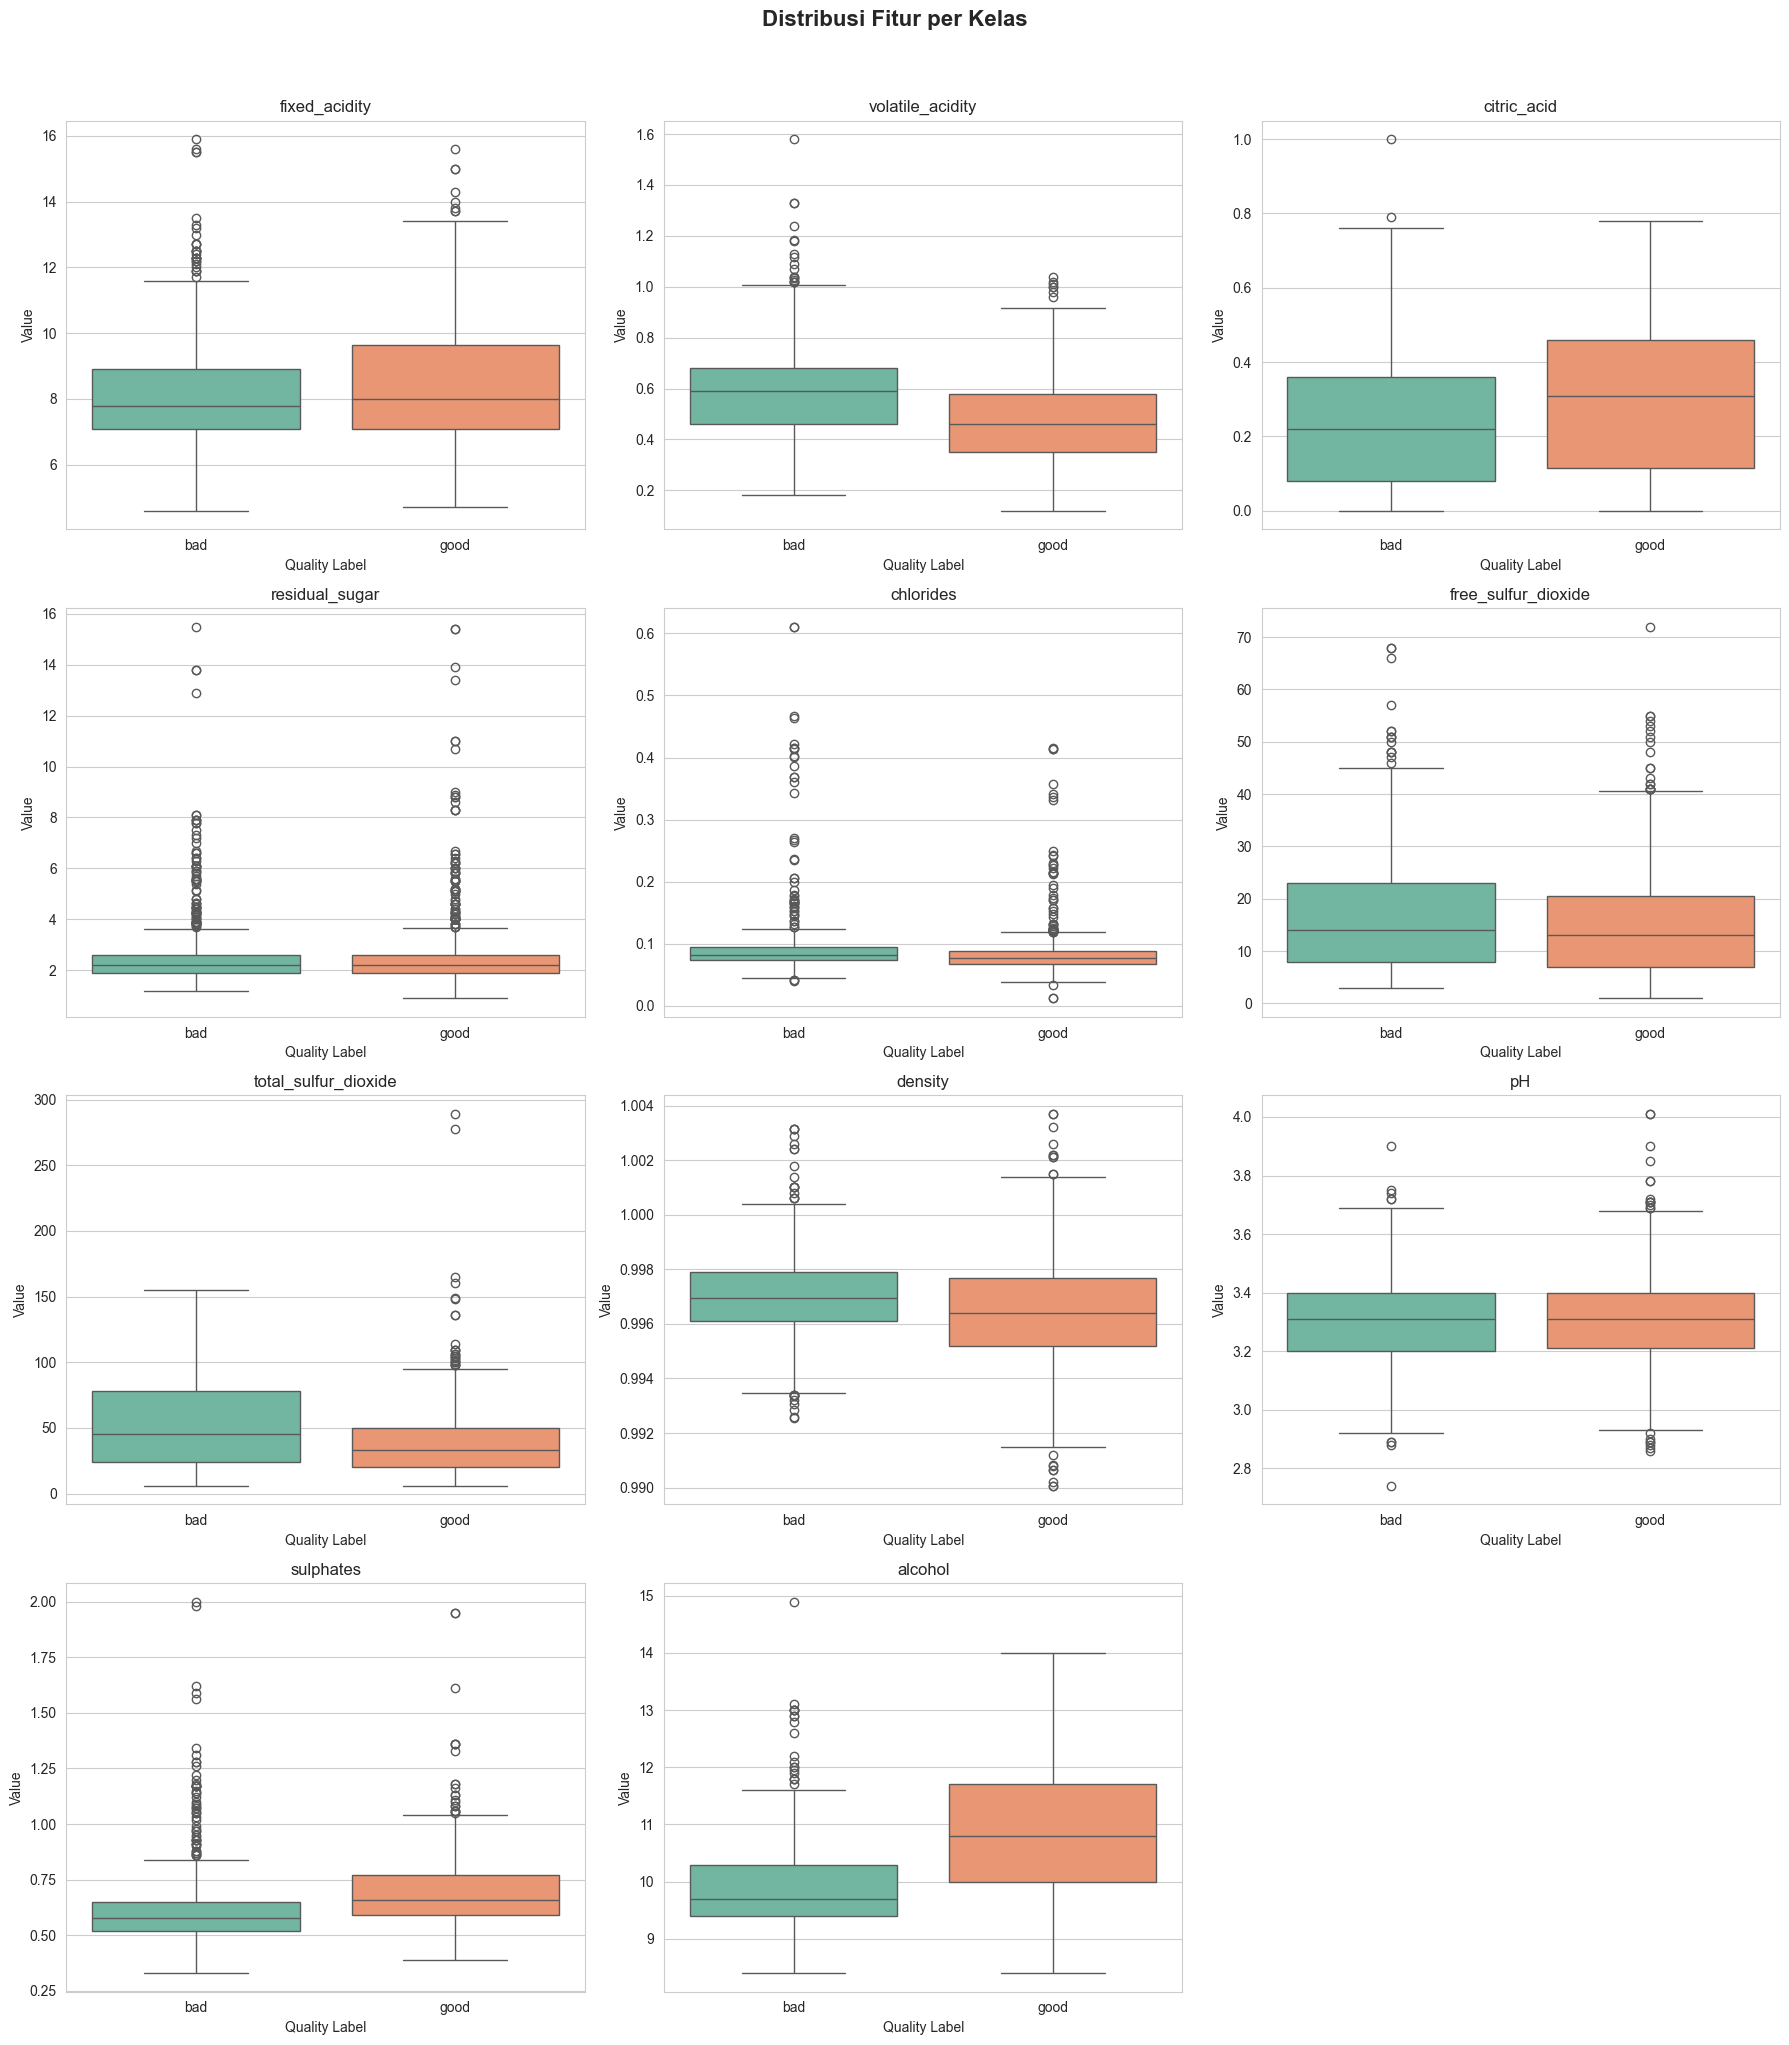

Boxplot fitur per kelas disimpan.


In [9]:
# Boxplot fitur per kelas
feature_cols = [c for c in df.columns if c != 'quality_label']

fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.boxplot(x='quality_label', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col}', fontsize=12)
    axes[i].set_xlabel('Quality Label')
    axes[i].set_ylabel('Value')

# Hapus axis kosong jika feature < axes
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribusi Fitur per Kelas', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_boxplot.png', dpi=100, bbox_inches='tight')
plt.show()
print('Boxplot fitur per kelas disimpan.')


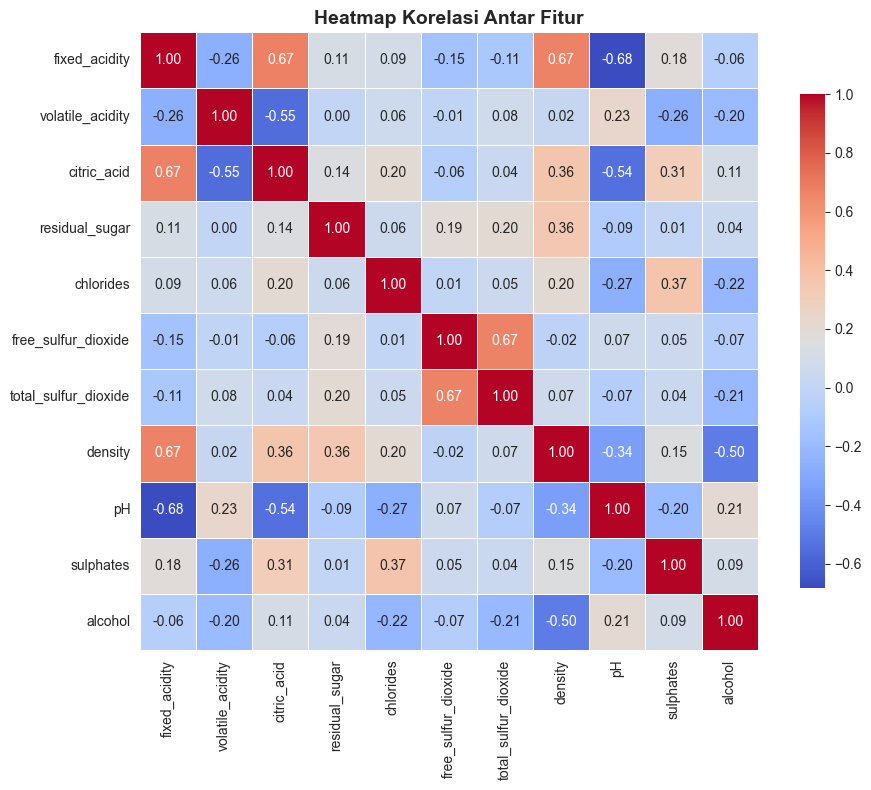

Korelasi tertinggi:
fixed_acidity         citric_acid            0.671703
                      density                0.668047
total_sulfur_dioxide  free_sulfur_dioxide    0.667666
sulphates             chlorides              0.371260
citric_acid           density                0.364947
dtype: float64


In [10]:
# Heatmap korelasi
numeric_df = df[feature_cols]
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Heatmap Korelasi Antar Fitur', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=100, bbox_inches='tight')
plt.show()

print('Korelasi tertinggi:')
corr_pairs = corr_matrix.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1.0].drop_duplicates()
print(corr_pairs.head(5))


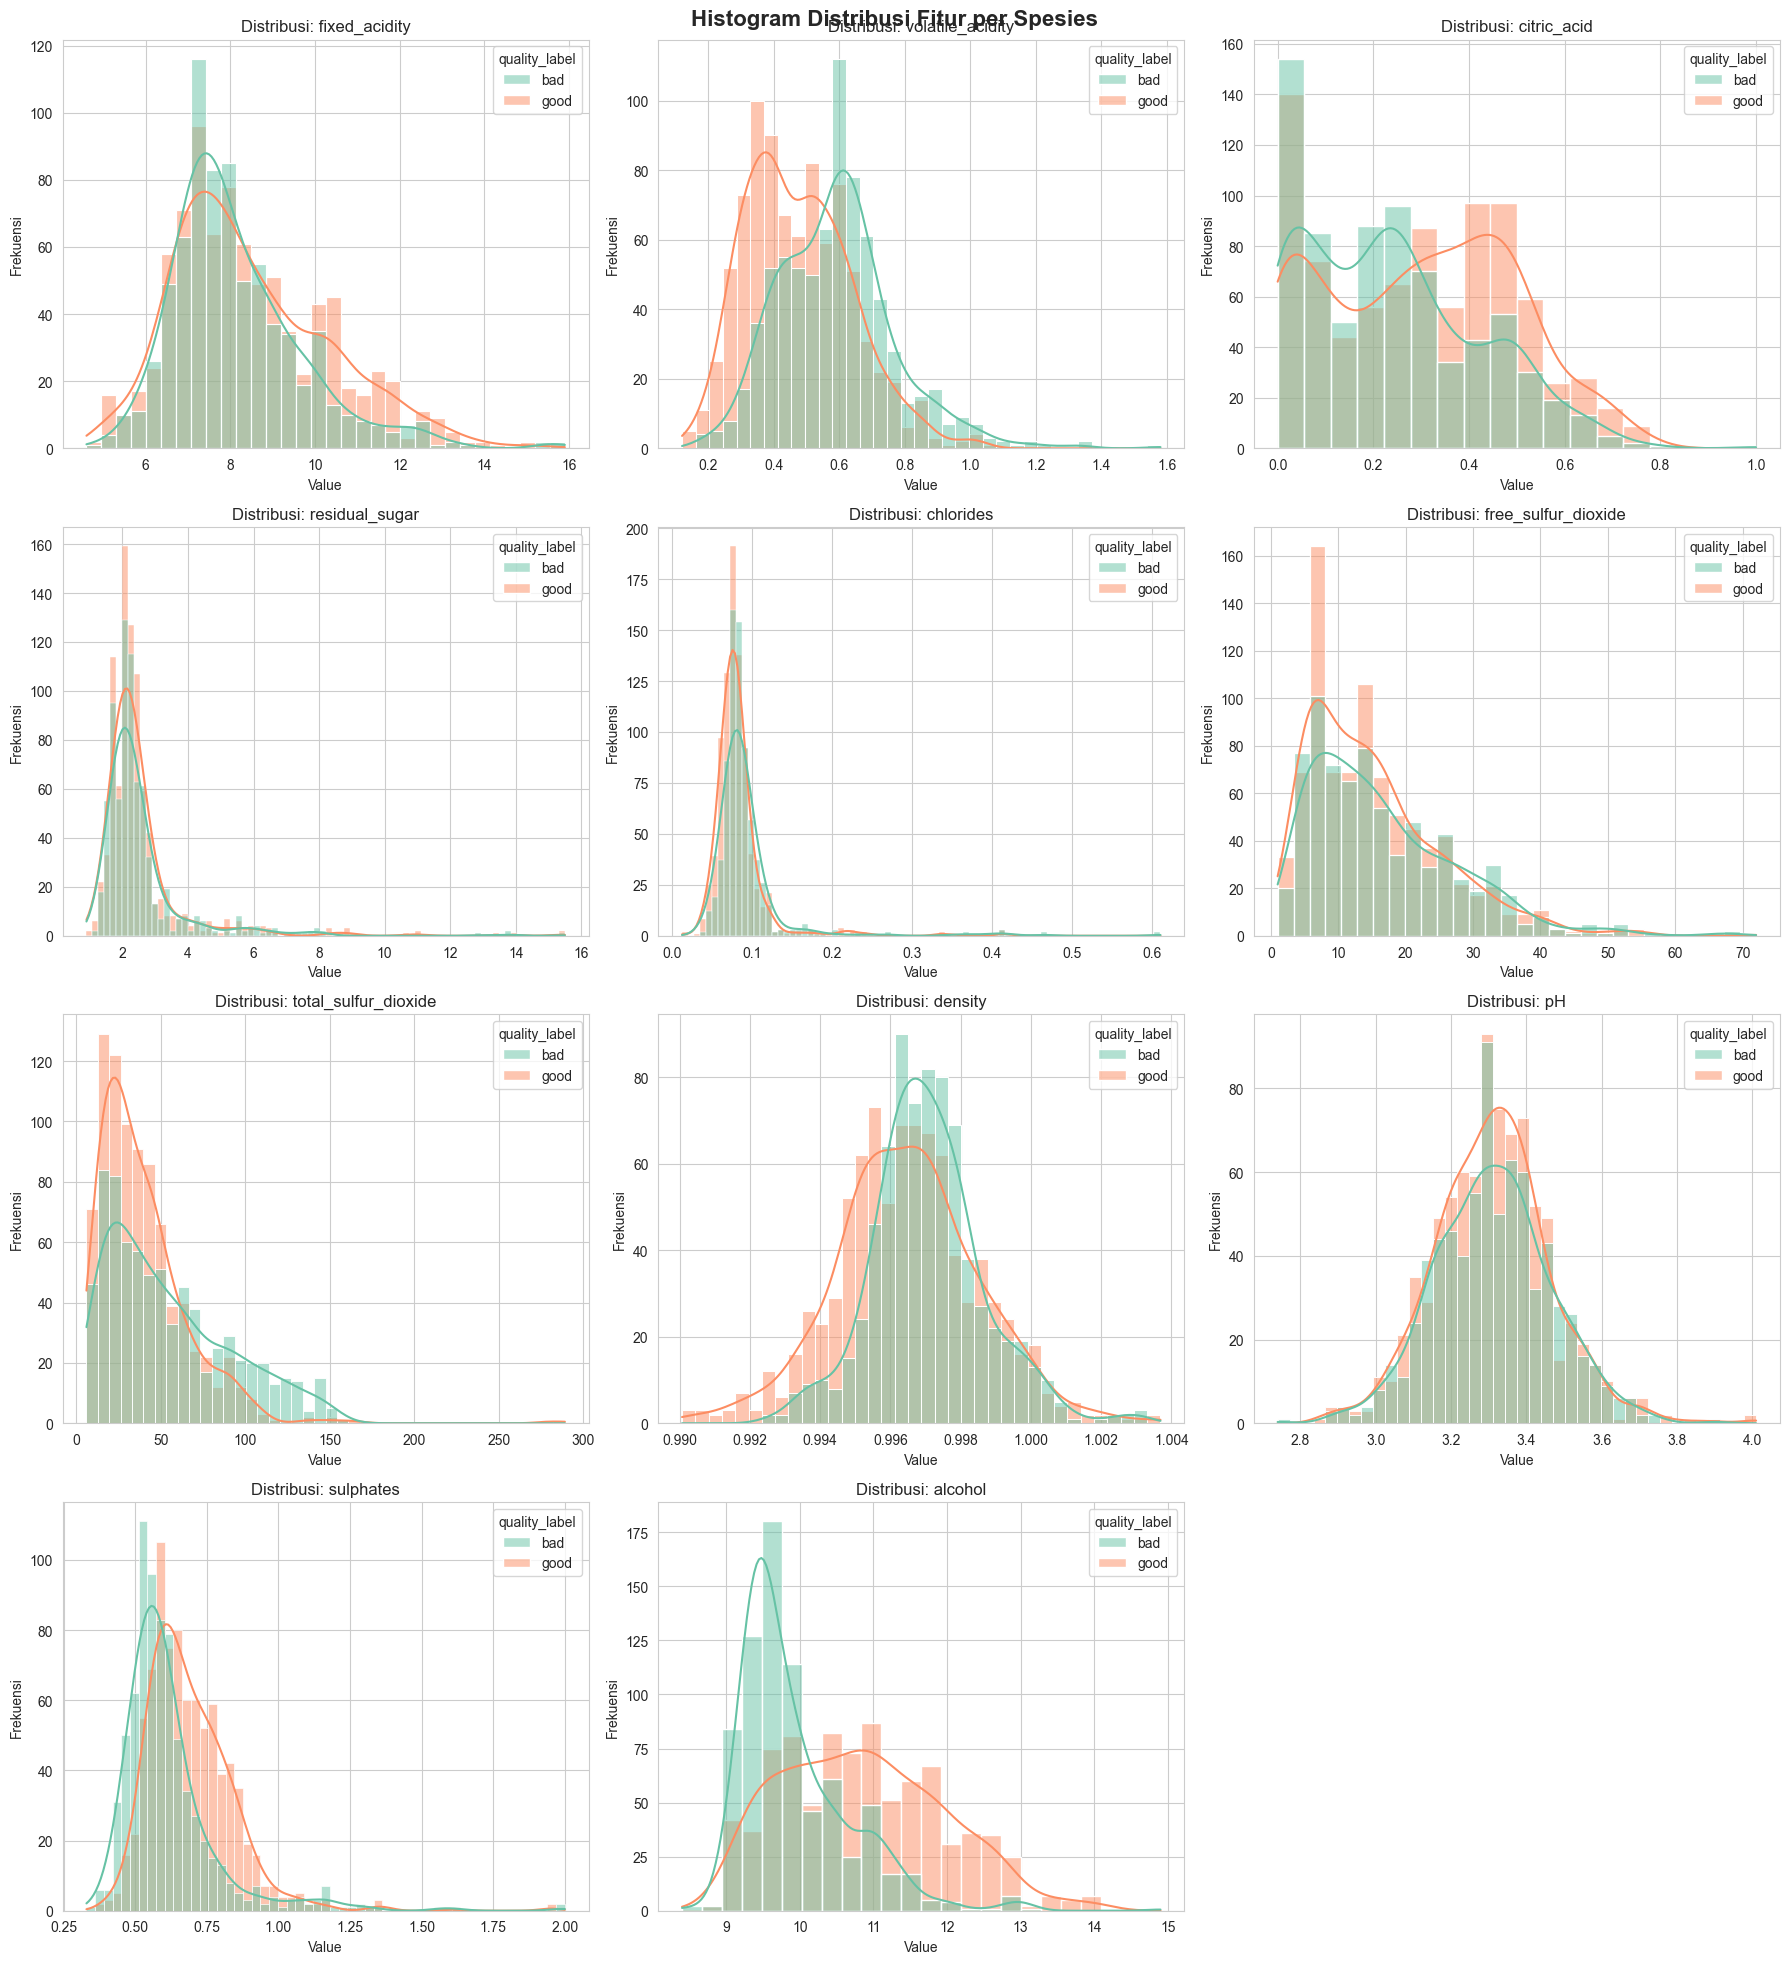

Histogram distribusi fitur disimpan.


In [11]:
# Histogram distribusi setiap fitur
fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.histplot(data=df, x=col, hue='quality_label', kde=True, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Distribusi: {col}', fontsize=12)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frekuensi')

# Hapus axis kosong
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Histogram Distribusi Fitur per Spesies', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_histogram.png', dpi=100, bbox_inches='tight')
plt.show()
print('Histogram distribusi fitur disimpan.')


## 4. Data Preprocessing


In [12]:
# Buat salinan dataframe untuk preprocessing
df_processed = df.copy()
print('Salinan dataframe dibuat untuk preprocessing.')
print(f'Shape awal: {df_processed.shape}')


Salinan dataframe dibuat untuk preprocessing.
Shape awal: (1599, 12)


In [13]:
# Handle missing values
print('=== Handling Missing Values ===')
print(f'Missing values sebelum: {df_processed.isnull().sum().sum()}')

# Isi dengan median
for col in feature_cols:
    if df_processed[col].isnull().any():
        median_val = df_processed[col].median()
        df_processed[col].fillna(median_val, inplace=True)
        print(f'  {col}: diisi dengan median = {median_val:.4f}')

print(f'Missing values sesudah: {df_processed.isnull().sum().sum()}')


=== Handling Missing Values ===
Missing values sebelum: 0
Missing values sesudah: 0


In [14]:
# Handle duplicates
print('=== Handling Duplicates ===')
print(f'Jumlah duplikat sebelum: {df_processed.duplicated().sum()}')
df_processed = df_processed.drop_duplicates().reset_index(drop=True)
print(f'Jumlah duplikat sesudah: {df_processed.duplicated().sum()}')
print(f'Shape setelah drop duplicates: {df_processed.shape}')


=== Handling Duplicates ===
Jumlah duplikat sebelum: 240
Jumlah duplikat sesudah: 0
Shape setelah drop duplicates: (1359, 12)


In [15]:
# Label Encoding target
print('=== Label Encoding ===')
le = LabelEncoder()
df_processed['quality_label'] = le.fit_transform(df_processed['quality_label'])

print('Mapping label encoding:')
for idx, cls in enumerate(le.classes_):
    print(f'  {cls} -> {idx}')

print(f'\nDistribusi setelah encoding:')
print(df_processed['quality_label'].value_counts().sort_index())


=== Label Encoding ===
Mapping label encoding:
  bad -> 0
  good -> 1

Distribusi setelah encoding:
quality_label
0    640
1    719
Name: count, dtype: int64


In [16]:
# Pisahkan features dan target
X = df_processed[feature_cols]
y = df_processed['quality_label']

print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'Fitur yang digunakan: {feature_cols}')

# Feature Scaling menggunakan StandardScaler
print('\n=== Feature Scaling (StandardScaler) ===')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols)

print('Statistik setelah scaling (mean harus mendekati 0, std mendekati 1):')
display(X_scaled.describe().loc[['mean', 'std']].round(4))


Features shape: (1359, 11)
Target shape: (1359,)
Fitur yang digunakan: ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol']

=== Feature Scaling (StandardScaler) ===
Statistik setelah scaling (mean harus mendekati 0, std mendekati 1):


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
mean,-0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000,-0.0000,0.0000
std,1.0004,1.0004,1.0004,1.0004,1.0004,1.0004,1.0004,1.0004,1.0004,1.0004,1.0004


In [17]:
# Train-Test Split
print('=== Train-Test Split ===')
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape:  {y_test.shape}')
print(f'\nProporsi split: {len(X_test)/len(X_scaled)*100:.1f}% test')

print('\nDistribusi kelas train:')
print(y_train.value_counts().sort_index())
print('\nDistribusi kelas test:')
print(y_test.value_counts().sort_index())


=== Train-Test Split ===
X_train shape: (1087, 11)
X_test shape:  (272, 11)
y_train shape: (1087,)
y_test shape:  (272,)

Proporsi split: 20.0% test

Distribusi kelas train:
quality_label
0    512
1    575
Name: count, dtype: int64

Distribusi kelas test:
quality_label
0    128
1    144
Name: count, dtype: int64


In [18]:
# Simpan hasil preprocessing
OUTPUT_DIR = 'wine_preprocessing'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Gabungkan X dan y lalu simpan
train_df = pd.concat(
    [X_train.reset_index(drop=True), y_train.reset_index(drop=True)],
    axis=1
)
test_df = pd.concat(
    [X_test.reset_index(drop=True), y_test.reset_index(drop=True)],
    axis=1
)

train_path = os.path.join(OUTPUT_DIR, 'train.csv')
test_path  = os.path.join(OUTPUT_DIR, 'test.csv')

train_df.to_csv(train_path, index=False)
test_df.to_csv(test_path, index=False)

print('=== Data Berhasil Disimpan ===')
print(f'Train data: {train_path} | Shape: {train_df.shape}')
print(f'Test data:  {test_path} | Shape: {test_df.shape}')
print(f'\nKolom output: {list(train_df.columns)}')


=== Data Berhasil Disimpan ===
Train data: wine_preprocessing\train.csv | Shape: (1087, 12)
Test data:  wine_preprocessing\test.csv | Shape: (272, 12)

Kolom output: ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality_label']


In [19]:
# Verifikasi hasil
print('=== Verifikasi Hasil Preprocessing ===')
train_check = pd.read_csv(train_path)
test_check  = pd.read_csv(test_path)

print(f'Train CSV shape: {train_check.shape}')
print(f'Test CSV shape:  {test_check.shape}')
print(f'\nKolom: {list(train_check.columns)}')
print(f'\nSample train data:')
display(train_check.head(3))
print(f'\nMissing values train: {train_check.isnull().sum().sum()}')
print(f'Missing values test:  {test_check.isnull().sum().sum()}')
print('\nPreprocessing selesai!')


=== Verifikasi Hasil Preprocessing ===
Train CSV shape: (1087, 12)
Test CSV shape:  (272, 12)

Kolom: ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality_label']

Sample train data:


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality_label
0,-0.812391,-0.434389,-0.830496,-0.091284,-0.914198,-0.947324,-1.042798,-1.696231,-0.063148,-0.051024,0.894623,1
1,-0.812391,-0.489045,-1.393258,-0.831030,-0.367182,1.542281,-0.264277,-1.246607,0.065902,-0.461331,0.894623,1
2,-0.063695,-0.543700,0.090387,-0.683081,-0.144324,1.063511,-0.054675,-0.363418,-0.385772,-0.695792,-0.122325,0



Missing values train: 0
Missing values test:  0

Preprocessing selesai!
